# Bootstrap Analysis for Self-Prioritization Effect (v4.4)

**Version 4.4**: 基于v4.3，新增一个版本

**输出两张图**:
1. **v4.3版本**: Strict=Aligned, Loose=Max
2. **v4.4版本**: Strict=Max, Loose=Max（便于比较Strict vs Loose）

In [10]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

print("Libraries loaded!")

Libraries loaded!


In [11]:
# Load data
data_path = Path("D:/GitHub_programe/GitHub/SPE_Database/1_Data")
output_path = Path("D:/GitHub_programe/GitHub/SPE_Database/3_Reports/Bootstrap/v4_legend_optimized")

clean_files = list(data_path.rglob("*_Clean.csv"))
print(f"Found {len(clean_files)} Clean.csv files")

all_data = []
for file_path in clean_files:
    try:
        df = pd.read_csv(file_path)
        df['Source'] = file_path.stem
        all_data.append(df)
    except Exception as e:
        print(f"Error: {file_path.name}: {e}")

merged_df = pd.concat(all_data, ignore_index=True)

if 'Label_Standardized_Identity' not in merged_df.columns:
    merged_df['Label_Standardized_Identity'] = merged_df['Shape_Standardized_Identity']

mismatch_df = merged_df[merged_df['Matching'] == 'Nonmatching'].copy()
print(f"Mismatch trials: {len(mismatch_df)}, Participants: {mismatch_df['Subject'].nunique()}")

Found 72 Clean.csv files
Mismatch trials: 853015, Participants: 1676


In [12]:
# Helper functions
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    mean1, mean2 = np.mean(group1), np.mean(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_sd = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (mean1 - mean2) / pooled_sd if pooled_sd != 0 else np.nan

def filter_valid_subjects(df, identity_column):
    valid = []
    for subject, subj_df in df.groupby('Subject'):
        ids = set(subj_df[identity_column].dropna().unique())
        if 'Self' in ids and 'Stranger' in ids and len(ids) >= 3:
            valid.append(subject)
    return valid

def process_data_strict(df, analysis_type='Shape'):
    if analysis_type == 'Shape':
        primary_col = 'Shape_Standardized_Identity'
        secondary_col = 'Label_Standardized_Identity'
    else:
        primary_col = 'Label_Standardized_Identity'
        secondary_col = 'Shape_Standardized_Identity'
    
    valid_subjects = filter_valid_subjects(df, primary_col)
    df_filtered = df[df['Subject'].isin(valid_subjects)].copy()
    df_filtered['Primary'] = df_filtered[primary_col].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    df_filtered['Secondary'] = df_filtered[secondary_col].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    
    mask = (
        (df_filtered['Primary'] == 'Self') |
        ((df_filtered['Primary'] == 'Stranger') & (df_filtered['Secondary'] != 'Self')) |
        (df_filtered['Primary'] == 'Other')
    )
    return df_filtered[mask].copy()

def process_data_loose(df, analysis_type='Shape'):
    primary_col = 'Shape_Standardized_Identity' if analysis_type == 'Shape' else 'Label_Standardized_Identity'
    df_filtered = df.copy()
    df_filtered['Primary'] = df_filtered[primary_col].apply(lambda x: x if x in ['Self', 'Stranger'] else 'Other')
    return df_filtered[df_filtered['Primary'].isin(['Self', 'Stranger'])].copy()

def calculate_cohens_d(df, measure='RT', min_trials=2):
    results = []
    for subject, subj_df in df.groupby('Subject'):
        self_data = subj_df[subj_df['Primary'] == 'Self']
        stranger_data = subj_df[subj_df['Primary'] == 'Stranger']
        
        if measure == 'RT':
            self_vals = self_data[self_data['ACC'] == 1]['RT_ms'].dropna().values
            stranger_vals = stranger_data[stranger_data['ACC'] == 1]['RT_ms'].dropna().values
        else:
            self_vals = self_data['ACC'].dropna().values
            stranger_vals = stranger_data['ACC'].dropna().values
        
        if len(self_vals) < min_trials or len(stranger_vals) < min_trials:
            continue
        d = cohens_d(stranger_vals, self_vals) if measure == 'RT' else cohens_d(self_vals, stranger_vals)
        if not np.isnan(d):
            results.append({'Subject': subject, 'Cohens_d': d})
    return pd.DataFrame(results)

def bootstrap_analysis(cohens_d_values, n_bootstrap=500, min_n=10, step=10, max_n=None):
    total_n = len(cohens_d_values)
    if total_n < min_n:
        return pd.DataFrame()
    max_n = min(max_n, total_n) if max_n else total_n
    sample_sizes = list(range(min_n, max_n + 1, step))
    if max_n % step != 0 and max_n not in sample_sizes:
        sample_sizes.append(max_n)
    sample_sizes = sorted(set(sample_sizes))
    
    results = []
    for n in sample_sizes:
        boot_means = [np.mean(np.random.choice(cohens_d_values, size=n, replace=True)) for _ in range(n_bootstrap)]
        results.append({
            'SampleSize': n,
            'Mean_d': np.mean(boot_means),
            'CI_lower': np.percentile(boot_means, 2.5),
            'CI_upper': np.percentile(boot_means, 97.5)
        })
    return pd.DataFrame(results)

print("Functions defined!")

Functions defined!


In [13]:
# Run analysis with both aligned and max versions
def run_analysis(data, filtering_type='Strict', n_bootstrap=500):
    results = {'aligned': {}, 'max': {}}
    
    print(f"\n=== {filtering_type} Filtering ===")
    
    for measure in ['RT', 'ACC']:
        data_filtered = data if measure == 'ACC' else data[data['Matching'] == 'Nonmatching'].copy()
        
        if filtering_type == 'Strict':
            shape_data = process_data_strict(data_filtered, 'Shape')
            label_data = process_data_strict(data_filtered, 'Label')
        else:
            shape_data = process_data_loose(data_filtered, 'Shape')
            label_data = process_data_loose(data_filtered, 'Label')
        
        shape_cohens = calculate_cohens_d(shape_data, measure)
        label_cohens = calculate_cohens_d(label_data, measure)
        
        print(f"  {measure} - Shape: {len(shape_cohens)}, Label: {len(label_cohens)}")
        
        # Aligned version
        max_n_aligned = min(len(shape_cohens), len(label_cohens))
        shape_boot_aligned = bootstrap_analysis(shape_cohens['Cohens_d'].values, n_bootstrap, max_n=max_n_aligned) if len(shape_cohens) > 0 else pd.DataFrame()
        label_boot_aligned = bootstrap_analysis(label_cohens['Cohens_d'].values, n_bootstrap, max_n=max_n_aligned) if len(label_cohens) > 0 else pd.DataFrame()
        
        # Max version
        shape_boot_max = bootstrap_analysis(shape_cohens['Cohens_d'].values, n_bootstrap) if len(shape_cohens) > 0 else pd.DataFrame()
        label_boot_max = bootstrap_analysis(label_cohens['Cohens_d'].values, n_bootstrap) if len(label_cohens) > 0 else pd.DataFrame()
        
        # Add Identity column
        for df in [shape_boot_aligned, label_boot_aligned, shape_boot_max, label_boot_max]:
            if not df.empty:
                df['Identity'] = 'Shape' if df is shape_boot_aligned or df is shape_boot_max else 'Label'
        
        results['aligned'][measure.lower()] = pd.concat([shape_boot_aligned, label_boot_aligned], ignore_index=True)
        results['max'][measure.lower()] = pd.concat([shape_boot_max, label_boot_max], ignore_index=True)
    
    return results

# Run analyses
print("=" * 80)
strict_results = run_analysis(mismatch_df, 'Strict', 500)

print("\n" + "=" * 80)
loose_results = run_analysis(mismatch_df, 'Loose', 500)


=== Strict Filtering ===
  RT - Shape: 792, Label: 610
  ACC - Shape: 782, Label: 590


=== Loose Filtering ===
  RT - Shape: 964, Label: 813
  ACC - Shape: 954, Label: 800


In [14]:
# Create figure function - each subplot has its own x-axis range
def create_figure(strict_rt, strict_acc, loose_rt, loose_acc, version_name='v4.3'):
    shape_color = '#2E86AB'
    label_color = '#A23B72'
    y_min, y_max = -0.4, 0.4
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    plot_configs = [
        (axes[0, 0], strict_rt, 'RT', 'Strict'),
        (axes[0, 1], strict_acc, 'ACC', 'Strict'),
        (axes[1, 0], loose_rt, 'RT', 'Loose'),
        (axes[1, 1], loose_acc, 'ACC', 'Loose'),
    ]
    
    for ax, data, measure, approach in plot_configs:
        ax.set_facecolor('white')
        ax.grid(False)
        
        if data.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes, fontsize=14)
            continue
        
        # Find max sample size for this subplot
        subplot_max_n = data['SampleSize'].max()
        
        for identity in ['Shape', 'Label']:
            subset = data[data['Identity'] == identity]
            if subset.empty:
                continue
            color = shape_color if identity == 'Shape' else label_color
            ax.plot(subset['SampleSize'], subset['Mean_d'], color=color, linewidth=2)
            ax.fill_between(subset['SampleSize'], subset['CI_lower'], subset['CI_upper'], color=color, alpha=0.2)
            ax.scatter(subset['SampleSize'], subset['Mean_d'], color=color, s=20, zorder=5)
        
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.set_xlim(0, subplot_max_n + 50)  # Each subplot has its own x-axis range
        ax.set_ylim(y_min, y_max)
        
        y_label = "Cohen's d (Stranger - Self)" if measure == 'RT' else "Cohen's d (Self - Stranger)"
        subplot_label = ('A' if approach == 'Strict' else 'C') if measure == 'RT' else ('B' if approach == 'Strict' else 'D')
        
        ax.set_xlabel('Sample Size', fontsize=12, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=12, fontweight='bold')
        ax.set_title(f"SPE calculated by {approach.lower()} approach", fontsize=13, fontweight='bold', family='Times New Roman', pad=20)
        
        ax.text(0.5, 1.02, f'({measure})', transform=ax.transAxes, fontsize=10, ha='right', va='bottom')
        ax.text(0.52, 1.02, ' ■', transform=ax.transAxes, fontsize=12, ha='left', va='bottom', color=shape_color, fontweight='bold')
        ax.text(0.58, 1.02, ' Shape  ', transform=ax.transAxes, fontsize=10, ha='left', va='bottom')
        ax.text(0.70, 1.02, '■', transform=ax.transAxes, fontsize=12, ha='left', va='bottom', color=label_color, fontweight='bold')
        ax.text(0.73, 1.02, ' Label', transform=ax.transAxes, fontsize=10, ha='left', va='bottom')
        ax.text(-0.08, 1.15, subplot_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
    
    plt.tight_layout()
    filename = f'combined_figures_{version_name}.png'
    plt.savefig(output_path / filename, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print(f"Saved: {filename}")



FIGURE 1: v4.3 VERSION
Strict = Aligned (样本量对齐), Loose = Max (各自最大)


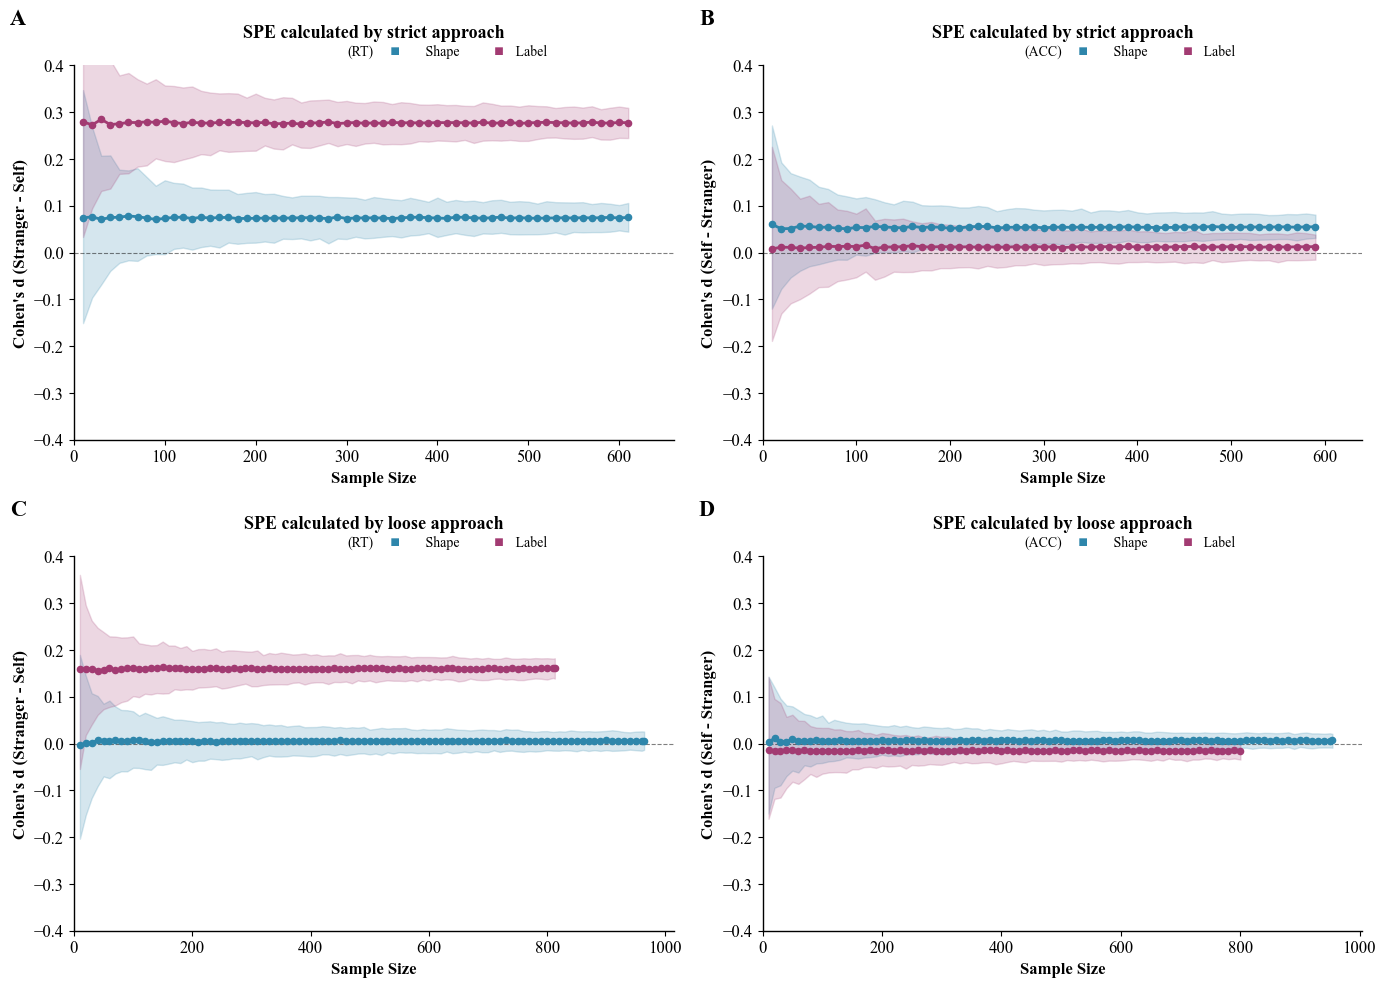

Saved: combined_figures_v4.3.png


In [15]:
# Generate Figure 1: v4.3 version (Strict=Aligned, Loose=Max)
print("\n" + "=" * 80)
print("FIGURE 1: v4.3 VERSION")
print("Strict = Aligned (样本量对齐), Loose = Max (各自最大)")
print("=" * 80)

create_figure(
    strict_results['aligned']['rt'],
    strict_results['aligned']['acc'],
    loose_results['max']['rt'],
    loose_results['max']['acc'],
    version_name='v4.3'
)


FIGURE 2: v4.4 VERSION
Strict = Max (各自最大), Loose = Max (各自最大)
便于比较Strict vs Loose的筛选效果


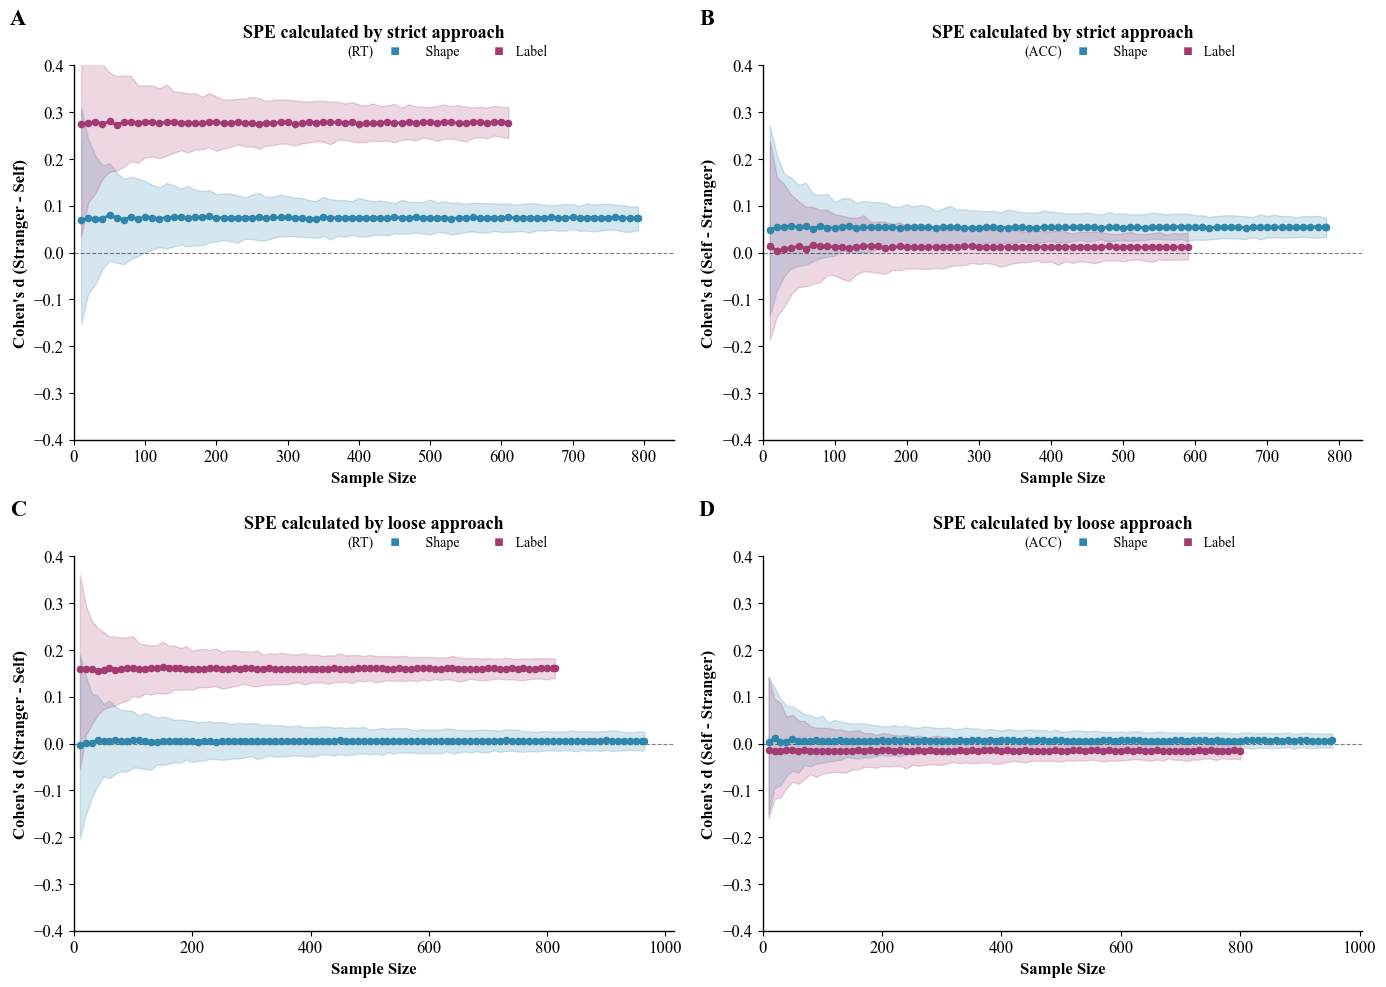

Saved: combined_figures_v4.4.png


In [16]:
# Generate Figure 2: v4.4 version (Strict=Max, Loose=Max)
print("\n" + "=" * 80)
print("FIGURE 2: v4.4 VERSION")
print("Strict = Max (各自最大), Loose = Max (各自最大)")
print("便于比较Strict vs Loose的筛选效果")
print("=" * 80)

create_figure(
    strict_results['max']['rt'],
    strict_results['max']['acc'],
    loose_results['max']['rt'],
    loose_results['max']['acc'],
    version_name='v4.4'
)

In [17]:
# Save all results
print("\n" + "=" * 80)
print("SAVING RESULTS")
print("=" * 80)

# v4.3 results
strict_results['aligned']['rt'].to_csv(output_path / 'bootstrap_rt_strict_aligned_v4.3.csv', index=False)
strict_results['aligned']['acc'].to_csv(output_path / 'bootstrap_acc_strict_aligned_v4.3.csv', index=False)
loose_results['max']['rt'].to_csv(output_path / 'bootstrap_rt_loose_max_v4.3.csv', index=False)
loose_results['max']['acc'].to_csv(output_path / 'bootstrap_acc_loose_max_v4.3.csv', index=False)

# v4.4 results
strict_results['max']['rt'].to_csv(output_path / 'bootstrap_rt_strict_max_v4.4.csv', index=False)
strict_results['max']['acc'].to_csv(output_path / 'bootstrap_acc_strict_max_v4.4.csv', index=False)

print("\nFiles saved:")
print("  - combined_figures_v4.3.png (Strict=Aligned, Loose=Max)")
print("  - combined_figures_v4.4.png (Strict=Max, Loose=Max)")
print("  - 6 CSV files")


SAVING RESULTS

Files saved:
  - combined_figures_v4.3.png (Strict=Aligned, Loose=Max)
  - combined_figures_v4.4.png (Strict=Max, Loose=Max)
  - 6 CSV files


In [18]:
# Print summary
print("\n" + "=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

print("\n--- Strict Filtering ---")
for version_name, version_data in [('Aligned', strict_results['aligned']), ('Max', strict_results['max'])]:
    print(f"\n{version_name} Version:")
    for measure in ['rt', 'acc']:
        data = version_data[measure]
        if not data.empty:
            print(f"  {measure.upper()}:")
            for identity in ['Shape', 'Label']:
                subset = data[data['Identity'] == identity]
                if not subset.empty:
                    max_n = subset['SampleSize'].max()
                    final = subset[subset['SampleSize'] == max_n].iloc[0]
                    sig = "Yes" if (final['CI_lower'] > 0 or final['CI_upper'] < 0) else "No"
                    print(f"    {identity}: N={max_n}, d={final['Mean_d']:.3f}, CI[{final['CI_lower']:.3f}, {final['CI_upper']:.3f}], Sig:{sig}")

print("\n--- Loose Filtering ---")
for measure in ['rt', 'acc']:
    data = loose_results['max'][measure]
    if not data.empty:
        print(f"  {measure.upper()}:")
        for identity in ['Shape', 'Label']:
            subset = data[data['Identity'] == identity]
            if not subset.empty:
                max_n = subset['SampleSize'].max()
                final = subset[subset['SampleSize'] == max_n].iloc[0]
                sig = "Yes" if (final['CI_lower'] > 0 or final['CI_upper'] < 0) else "No"
                print(f"    {identity}: N={max_n}, d={final['Mean_d']:.3f}, CI[{final['CI_lower']:.3f}, {final['CI_upper']:.3f}], Sig:{sig}")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)


ANALYSIS SUMMARY

--- Strict Filtering ---

Aligned Version:
  RT:
    Shape: N=610, d=0.075, CI[0.045, 0.106], Sig:Yes
    Label: N=610, d=0.278, CI[0.245, 0.309], Sig:Yes
  ACC:
    Shape: N=590, d=0.055, CI[0.031, 0.081], Sig:Yes
    Label: N=590, d=0.013, CI[-0.015, 0.039], Sig:No

Max Version:
  RT:
    Shape: N=792, d=0.073, CI[0.047, 0.099], Sig:Yes
    Label: N=610, d=0.278, CI[0.245, 0.311], Sig:Yes
  ACC:
    Shape: N=782, d=0.054, CI[0.032, 0.076], Sig:Yes
    Label: N=590, d=0.012, CI[-0.015, 0.043], Sig:No

--- Loose Filtering ---
  RT:
    Shape: N=964, d=0.005, CI[-0.013, 0.026], Sig:No
    Label: N=813, d=0.161, CI[0.139, 0.182], Sig:Yes
  ACC:
    Shape: N=954, d=0.007, CI[-0.009, 0.021], Sig:No
    Label: N=800, d=-0.015, CI[-0.034, 0.002], Sig:No

ANALYSIS COMPLETE!


## Summary

### 两张图的区别

| 图表 | Strict | Loose | 用途 |
|------|--------|-------|------|
| **v4.3** | Aligned (对齐) | Max (最大) | 比较Shape vs Label |
| **v4.4** | Max (最大) | Max (最大) | 比较Strict vs Loose |

### 输出文件
- `combined_figures_v4.3.png`
- `combined_figures_v4.4.png`